# MLOps Project: MNIST Handwritten Digit Classification 

This is an end to end Machine Learning Pipeline with Retraining Capability

## Imports

In [1]:
### Import Libraries

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.15.0
NumPy version: 1.24.3


## Data acquisition and Loading

In [3]:
# Load MNIST dataset
print("\nLoading MNIST dataset...")
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"Training data shape: {x_train_full.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Number of classes: {len(np.unique(y_train_full))}")


Loading MNIST dataset...
11490434/11490434 [==============================] - 9s 1us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Number of classes: 10


## Data Exploration and Visualizations

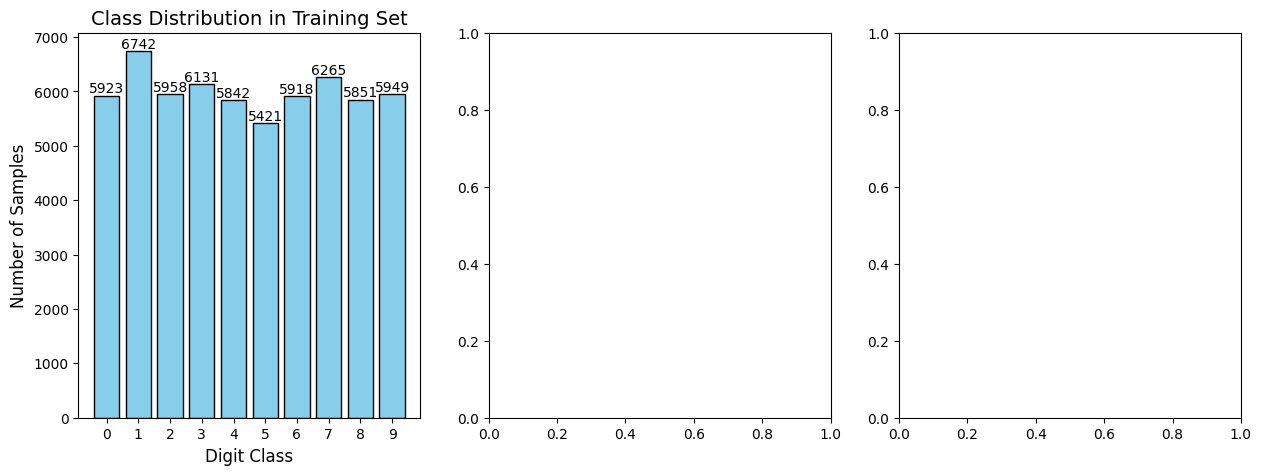

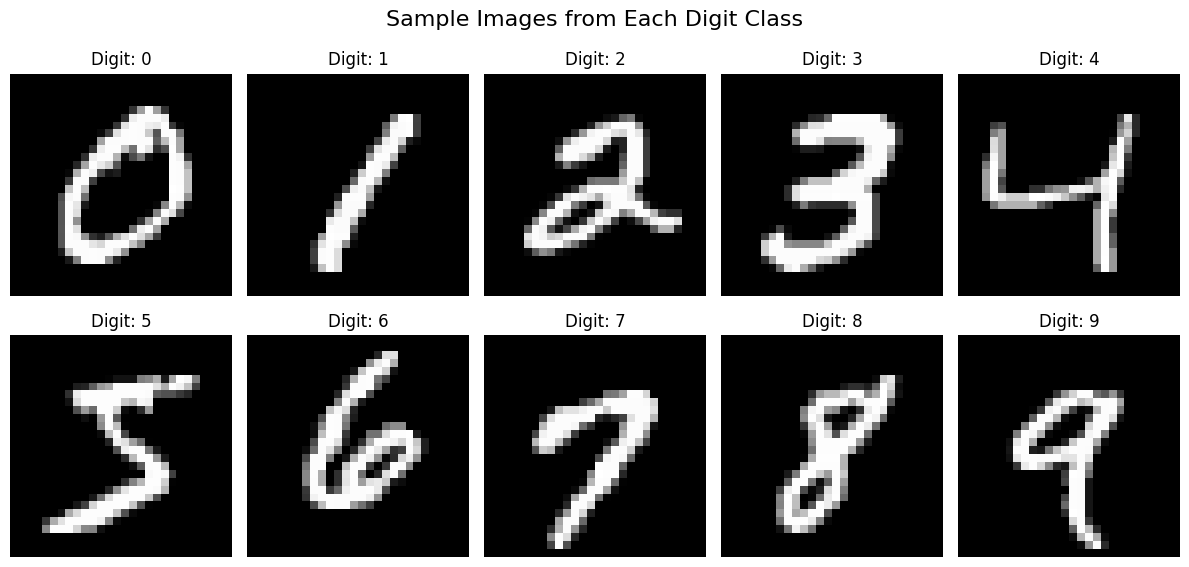

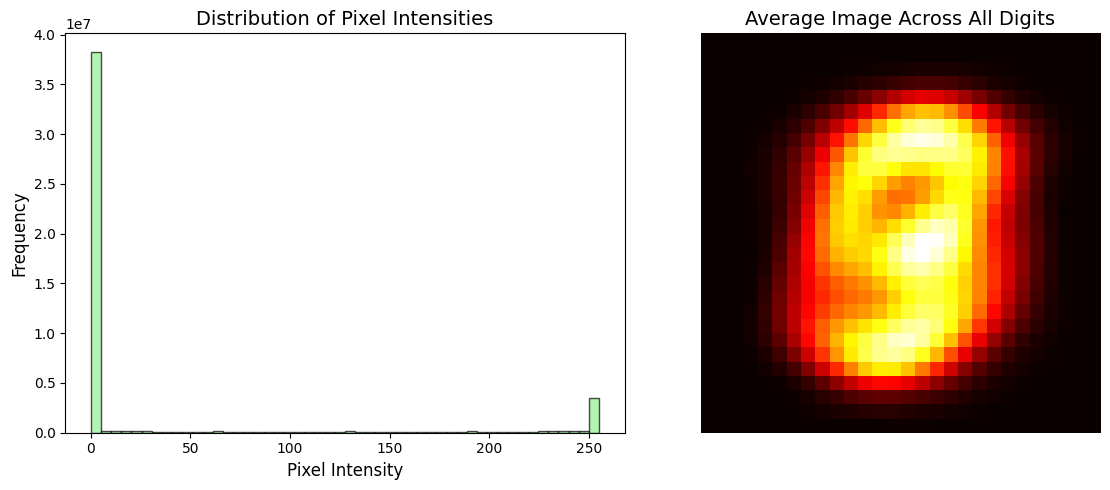


 Data Insights:
1. The dataset is balanced with approximately 6,000 samples per digit class
2. Images are 28x28 pixels (784 features) with grayscale values 0-255
3. Pixel intensities are mostly concentrated around 0 (background) and 255 (foreground)
4. Some digits like '1' have thinner strokes compared to digits like '8'


In [4]:
# Visualization 1: Class Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Class distribution in training set
unique, counts = np.unique(y_train_full, return_counts=True)
axes[0].bar(unique, counts, color='skyblue', edgecolor='black')
axes[0].set_title('Class Distribution in Training Set', fontsize=14)
axes[0].set_xlabel('Digit Class', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_xticks(unique)

# Add value labels on bars
for i, count in enumerate(counts):
    axes[0].text(i, count + 50, str(count), ha='center', fontsize=10)

# Visualization 2: Sample Images from Each Class
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for digit in range(10):
    # Find first occurrence of each digit
    idx = np.where(y_train_full == digit)[0][0]
    axes[digit].imshow(x_train_full[idx], cmap='gray')
    axes[digit].set_title(f'Digit: {digit}', fontsize=12)
    axes[digit].axis('off')

plt.suptitle('Sample Images from Each Digit Class', fontsize=16)
plt.tight_layout()
plt.show()

# Visualization 3: Pixel Intensity Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribution of pixel values
pixel_values = x_train_full.flatten()
axes[0].hist(pixel_values, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Pixel Intensities', fontsize=14)
axes[0].set_xlabel('Pixel Intensity', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Average digit image per class
class_means = []
for digit in range(10):
    digit_images = x_train_full[y_train_full == digit]
    class_means.append(np.mean(digit_images, axis=0))

class_mean_img = np.mean(class_means, axis=0)
axes[1].imshow(class_mean_img, cmap='hot')
axes[1].set_title('Average Image Across All Digits', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n Data Insights:")
print("1. The dataset is balanced with approximately 6,000 samples per digit class")
print("2. Images are 28x28 pixels (784 features) with grayscale values 0-255")
print("3. Pixel intensities are mostly concentrated around 0 (background) and 255 (foreground)")
print("4. Some digits like '1' have thinner strokes compared to digits like '8'")

## Data Preprocessing

In [5]:
print("\n Preprocessing data...")

# Normalize pixel values to [0, 1]
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Add channel dimension (for CNN)
x_train_full = np.expand_dims(x_train_full, -1)
x_test = np.expand_dims(x_test, -1)

# Split training into train and validation sets
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"Training set: {x_train.shape}")
print(f"Validation set: {x_val.shape}")
print(f"Test set: {x_test.shape}")

# One-hot encode labels
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_val_cat = tf.keras.utils.to_categorical(y_val, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

# ### 5. Model Creation with Optimization Techniques

print("\n Building CNN model with optimization techniques...")

# Create model with regularization, dropout, and batch normalization
model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                  kernel_regularizer=regularizers.l2(0.001), 
                  input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Dense Layers
    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compile model with Adam optimizer
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# Display model architecture
model.summary()

# Callbacks for optimization
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('../models/mnist_cnn.h5', monitor='val_accuracy', 
                    save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)
]


 Preprocessing data...
Training set: (48000, 28, 28, 1)
Validation set: (12000, 28, 28, 1)
Test set: (10000, 28, 28, 1)

 Building CNN model with optimization techniques...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 batch_normalization (Batch  (None, 28, 28, 32)        128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 14, 14, 32)        0         
                                                                 
 conv2d_1 (C

## Model Training

In [6]:
print("\n Training model...")

history = model.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=50,
    validation_data=(x_val, y_val_cat),
    callbacks=callbacks,
    verbose=1
)


 Training model...
Epoch 1/50


375/375 [==============================] - ETA: 0s - loss: 1.1841 - accuracy: 0.8413 - precision: 0.8997 - recall: 0.8044
Epoch 1: val_accuracy improved from -inf to 0.18583, saving model to ../models\mnist_cnn.h5
375/375 [==============================] - 51s 115ms/step - loss: 1.1841 - accuracy: 0.8413 - precision: 0.8997 - recall: 0.8044 - val_loss: 4.2630 - val_accuracy: 0.1858 - val_precision: 0.1830 - val_recall: 0.1800 - lr: 0.0010
Epoch 2/50
375/375 [==============================] - ETA: 0s - loss: 0.6344 - accuracy: 0.9588 - precision: 0.9667 - recall: 0.9521
Epoch 2: val_accuracy improved from 0.18583 to 0.98250, saving model to ../models\mnist_cnn.h5
375/375 [==============================] - 43s 116ms/step - loss: 0.6344 - accuracy: 0.9588 - precision: 0.9667 - recall: 0.9521 - val_loss: 0.4783 - val_accuracy: 0.9825 - val_precision: 0.9848 - val_recall: 0.9795 - lr: 0.0010
Epoch 3/50
375/375 [==============================] - ETA: 0s - los

## Model Evaluation with Multiple Metrics


 Evaluating model on test set...
313/313 [==============================] - 3s 8ms/step

MODEL PERFORMANCE METRICS
 Test Accuracy:  0.9955 (99.55%)
 Test Loss:     0.0543
 Test Precision: 0.9956
 Test Recall:    0.9955
 Test F1-Score:  0.9955
\ Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      1.00      1032
           3       1.00      1.00      1.00      1010
           4       1.00      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      1.00       958
           7       1.00      0.99      1.00      1028
           8       1.00      0.99      0.99       974
           9       1.00      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg      

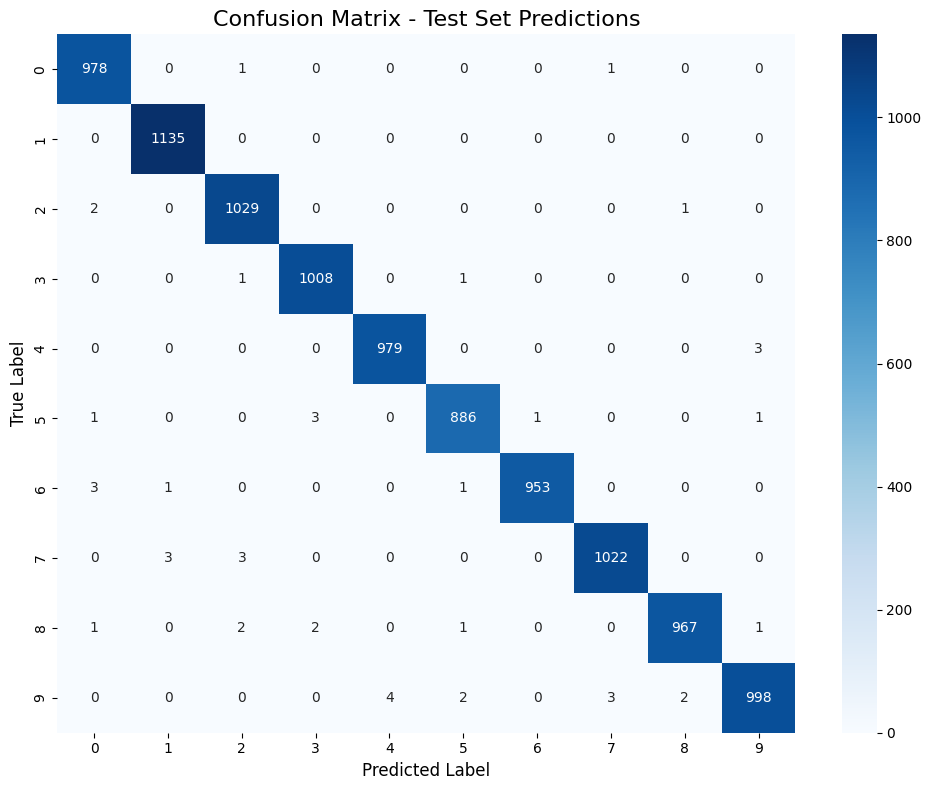

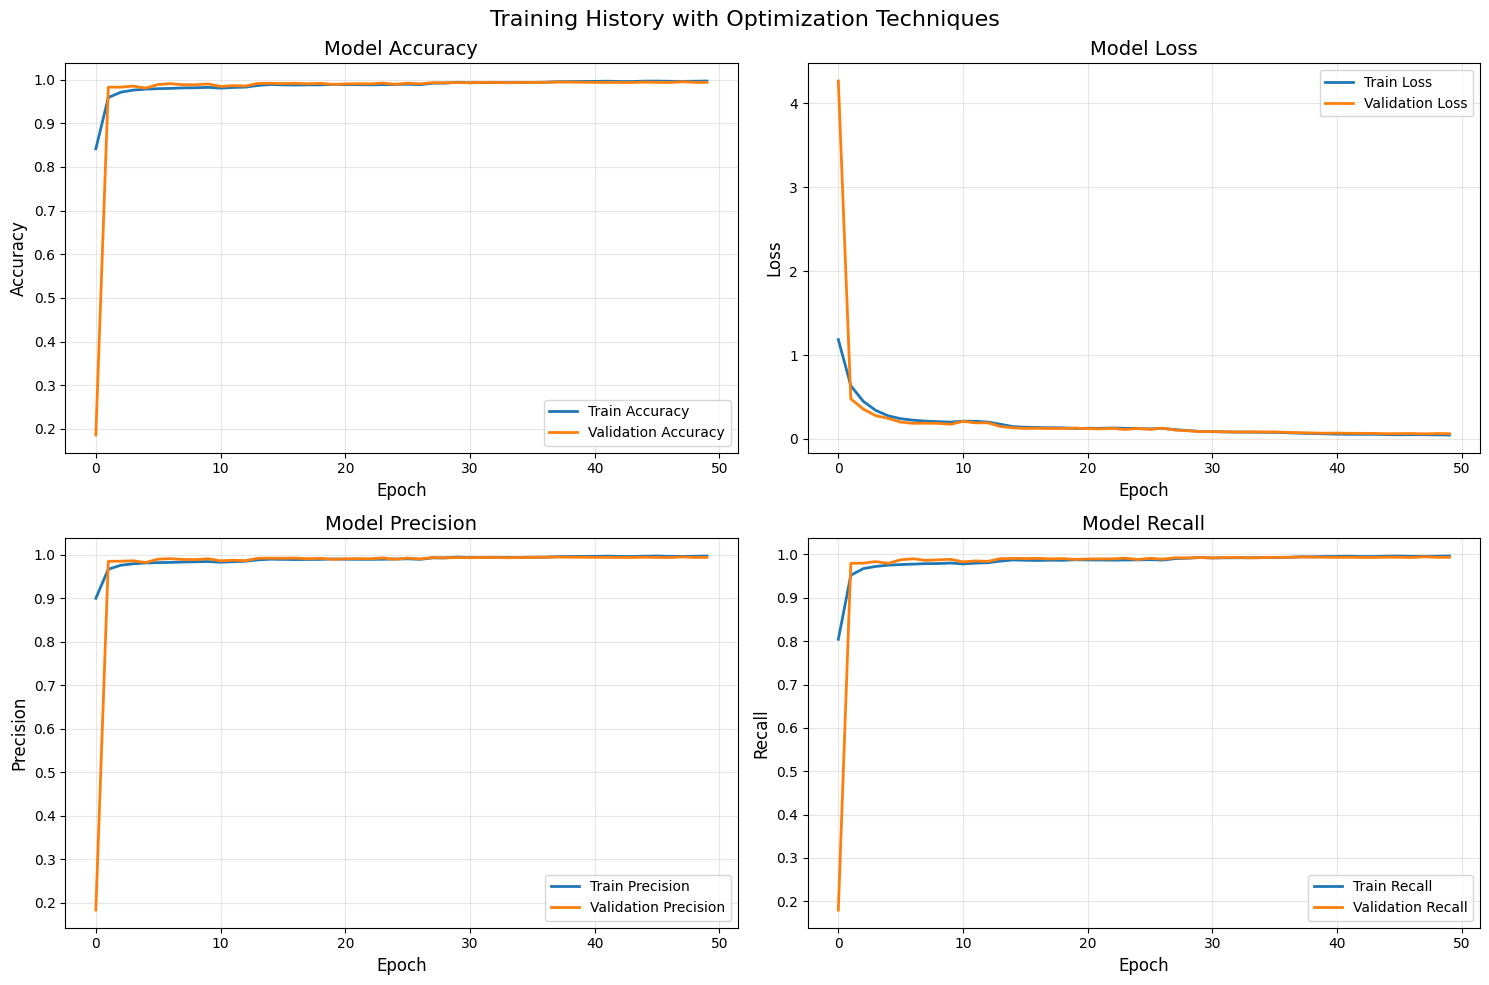

In [7]:
print("\n Evaluating model on test set...")

# Predict on test set
y_pred_proba = model.predict(x_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test

# Calculate multiple evaluation metrics
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(x_test, y_test_cat, verbose=0)
test_f1 = f1_score(y_true, y_pred, average='weighted')

print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f" Test Accuracy:  {test_accuracy:.4f} ({(test_accuracy*100):.2f}%)")
print(f" Test Loss:     {test_loss:.4f}")
print(f" Test Precision: {test_precision:.4f}")
print(f" Test Recall:    {test_recall:.4f}")
print(f" Test F1-Score:  {test_f1:.4f}")
print("="*50)

# Detailed classification report
print("\ Detailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(10)]))

# **Visualization 4: Confusion Matrix**
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Test Set Predictions', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# **Visualization 5: Training History**
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].set_title('Model Accuracy', fontsize=14)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].set_title('Model Loss', fontsize=14)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train Precision', linewidth=2)
axes[1, 0].plot(history.history['val_precision'], label='Validation Precision', linewidth=2)
axes[1, 0].set_title('Model Precision', fontsize=14)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train Recall', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', linewidth=2)
axes[1, 1].set_title('Model Recall', fontsize=14)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Recall', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training History with Optimization Techniques', fontsize=16)
plt.tight_layout()
plt.show()

## Misclassification Analysis


 Misclassification Analysis:
Total misclassified: 45 out of 10000 (0.45%)


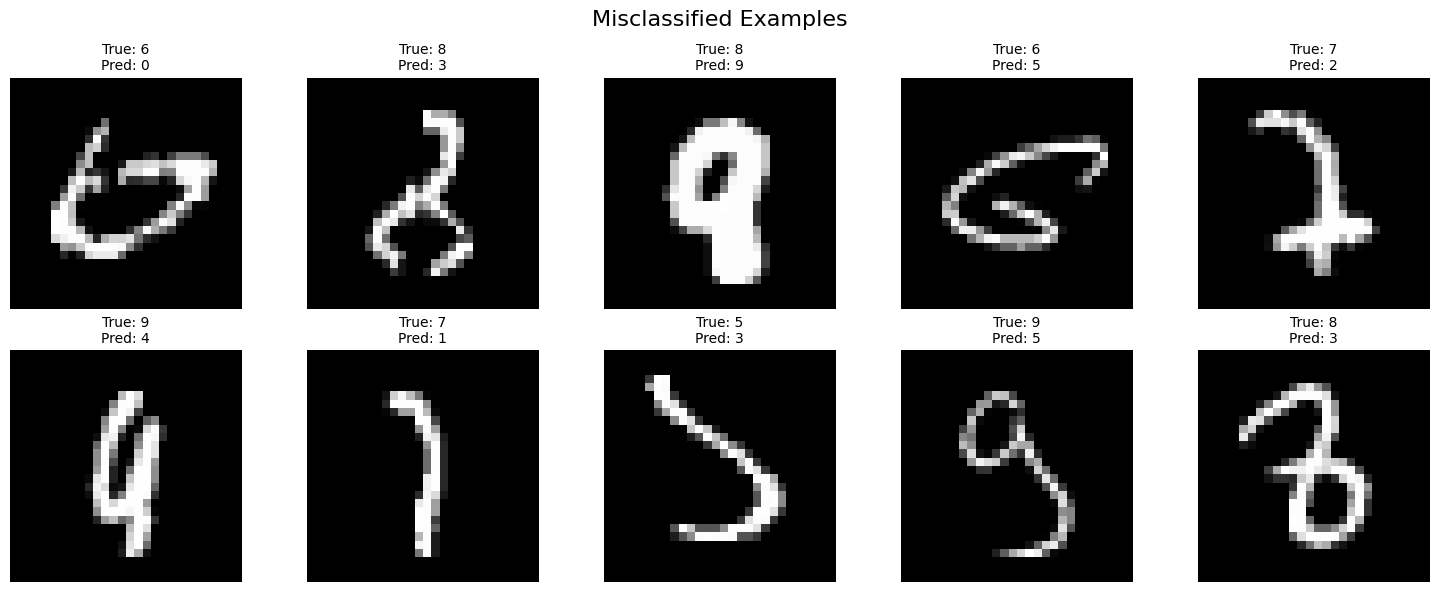

In [8]:
# Find misclassified examples
misclassified_idx = np.where(y_pred != y_true)[0]
misclassified_images = x_test[misclassified_idx]
misclassified_true = y_true[misclassified_idx]
misclassified_pred = y_pred[misclassified_idx]

print(f"\n Misclassification Analysis:")
print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_test)} ({len(misclassified_idx)/len(y_test)*100:.2f}%)")

# Display some misclassified examples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(min(10, len(misclassified_idx))):
    axes[i].imshow(misclassified_images[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"True: {misclassified_true[i]}\nPred: {misclassified_pred[i]}", fontsize=10)
    axes[i].axis('off')

plt.suptitle('Misclassified Examples', fontsize=16)
plt.tight_layout()
plt.show()

## Save Model

In [9]:
print("\n Saving model...")
model.save('../models/mnist_cnn.h5')
print(" Model saved successfully!")



 Saving model...
 Model saved successfully!


## Model Performance Summary

In [10]:
print("\n" + "="*60)
print(" FINAL MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"Architecture: CNN with 3 Conv Layers + 2 Dense Layers")
print(f"Optimization Techniques Applied:")
print("  • L2 Regularization (0.001)")
print("  • Batch Normalization")
print("  • Dropout (0.25-0.5)")
print("  • Early Stopping (patience=5)")
print("  • Learning Rate Reduction")
print(f"\nMetrics on Test Set:")
print(f"  • Accuracy:  {test_accuracy*100:.2f}%")
print(f"  • Precision: {test_precision*100:.2f}%")
print(f"  • Recall:    {test_recall*100:.2f}%")
print(f"  • F1-Score:  {test_f1*100:.2f}%")
print("="*60)

print("\n Notebook execution completed successfully!")


 FINAL MODEL PERFORMANCE SUMMARY
Architecture: CNN with 3 Conv Layers + 2 Dense Layers
Optimization Techniques Applied:
  • L2 Regularization (0.001)
  • Batch Normalization
  • Dropout (0.25-0.5)
  • Early Stopping (patience=5)
  • Learning Rate Reduction

Metrics on Test Set:
  • Accuracy:  99.55%
  • Precision: 99.56%
  • Recall:    99.55%
  • F1-Score:  99.55%

 Notebook execution completed successfully!
